# Data Understanding
The first part of this assignment is to explore the data and to define the machine learning task. You should perform EDA as an initial step to analyse the liver cirrhosis set. The analyses should be conducted on the given training set. The analyses should explore the data from the four different aspects:
-  Describe the summary statistics of the data. This should include the number of instances and number of features. Report the number of categorical and numerical features separately. 
- Identify the top three numerical features with the highest Pearson correlation with the target variable Status, and report their correlation values.
- Plot the distributions of the three numerical features identified in the previous question and the target variable using histograms. One histogram for each feature/variable. Describe how to determine the number of bins to draw the histograms. Based on the histograms, describe the shape of their distributions (i.e. Positive or Negative or Zero) with respect to their skewness and kurtosis.
- Check for missing values. Write a paragraph to briefly summarise how many features containing missing values and the percentage of missing values for each incomplete feature.

Provide answers to above questions in your report. Submit your Jupyter Notebook file (EDA.ipynb) or your Python file (EDA.py) that shows how you get the answers.

In [43]:
# Load our VIPs (very important packages)
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import numpy as np
import seaborn as sns # for data visualization
import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv('Training.csv')
df = df.rename(columns={'Tryglicerides': 'Triglycerides'})
df.head()

,Status,Drug,Age,Sex,Ascites,Hepatomegaly,Spiders,Edema,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Triglycerides,Platelets,Prothrombin,Stage
0,0,D-penicillamine,19567,F,N,Y,N,S,2.3,260.0,3.18,231.0,11320.2,105.78,94.0,216.0,12.4,3.0
1,0,Placebo,17246,F,N,Y,N,N,2.1,262.0,3.48,58.0,2045.0,89.90,84.0,225.0,11.5,4.0
2,1,Placebo,17874,F,N,Y,N,S,8.7,310.0,3.89,107.0,637.0,117.00,242.0,298.0,9.6,2.0
3,0,D-penicillamine,15895,F,Y,Y,Y,S,17.1,674.0,2.53,207.0,2078.0,182.90,598.0,268.0,11.5,4.0
4,0,Placebo,24650,F,N,Y,N,N,8.0,468.0,2.81,139.0,2009.0,198.40,139.0,233.0,10.0,4.0


In [ ]:
# Summary Statisics
## Number of Instances
## Number of Features
## Number of categorical and numerical features separately

In [3]:
df.shape

(334, 18)

In [4]:
categoricalFactors = ['Status', 'Drug', 'Sex', 'Ascites', 'Hepatomegaly', 'Spiders', 'Edema', 'Stage']
df[categoricalFactors] = df[categoricalFactors].astype('category')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 334 entries, 0 to 333
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   Status         334 non-null    category
 1   Drug           254 non-null    category
 2   Age            334 non-null    int64   
 3   Sex            334 non-null    category
 4   Ascites        254 non-null    category
 5   Hepatomegaly   254 non-null    category
 6   Spiders        254 non-null    category
 7   Edema          334 non-null    category
 8   Bilirubin      334 non-null    float64 
 9   Cholesterol    232 non-null    float64 
 10  Albumin        334 non-null    float64 
 11  Copper         252 non-null    float64 
 12  Alk_Phos       254 non-null    float64 
 13  SGOT           254 non-null    float64 
 14  Triglycerides  232 non-null    float64 
 15  Platelets      325 non-null    float64 
 16  Prothrombin    332 non-null    float64 
 17  Stage          329 non-null    cate

In [5]:
df.describe()
# Missing values in Cholesterol, Copper, Alk_Phos, SGOT, Tryglicerides, Platelets, Prothrombin, and Stage

,Age,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Triglycerides,Platelets,Prothrombin
count,334.000000,334.000000,232.000000,334.000000,252.000000,254.000000,254.000000,232.000000,325.000000,332.000000
mean,18458.628743,3.353892,373.297414,3.506437,98.162698,1967.518898,123.388425,124.668103,260.218462,10.764458
std,3860.211171,4.551418,247.550620,0.423248,89.603383,2130.869240,57.066844,67.516406,98.882826,1.080674
min,9598.000000,0.300000,120.000000,1.960000,9.000000,289.000000,26.350000,33.000000,62.000000,9.000000
25%,15593.500000,0.800000,247.000000,3.260000,41.500000,862.500000,80.485000,84.000000,192.000000,10.000000
50%,18414.000000,1.350000,308.500000,3.550000,71.500000,1288.500000,116.250000,108.000000,252.000000,10.600000
75%,21231.500000,3.575000,396.750000,3.777500,121.000000,2031.500000,153.450000,149.000000,319.000000,11.100000
max,28650.000000,28.000000,1775.000000,4.640000,588.000000,13862.400000,457.250000,598.000000,721.000000,18.000000


In [6]:
df.describe(include='category')

,Status,Drug,Sex,Ascites,Hepatomegaly,Spiders,Edema,Stage
count,334,254,334,254,254,254,334,329.0
unique,2,2,2,2,2,2,3,4.0
top,1,D-penicillamine,F,N,N,N,N,3.0
freq,205,131,300,236,128,180,284,126.0


In [ ]:
# Top three numerical features with highest Pearson correlation with target variable `status` and their correlation values

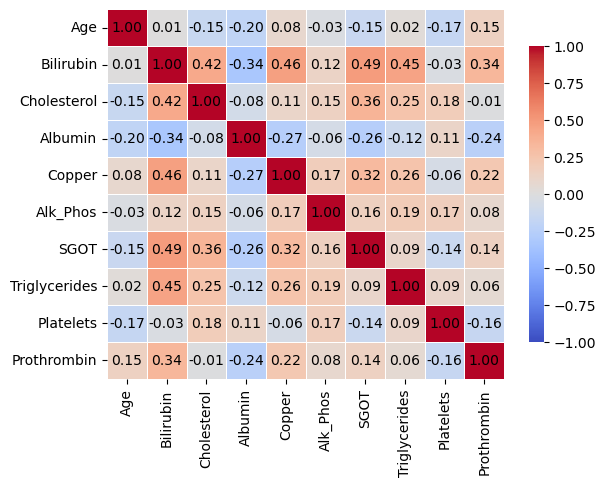

In [ ]:
correlationMatrix = df.corr(numeric_only=True)

# Create heatmap without annotations
ax = sns.heatmap(
    correlationMatrix, 
    cmap='coolwarm', 
    linewidths=0.5, 
    vmin=-1, vmax=1, 
    cbar_kws={"shrink": 0.8}
)

# Manually add text annotations for every cell
for i in range(correlationMatrix.shape[0]):
    for j in range(correlationMatrix.shape[1]):
        plt.text(
            j + 0.5,  # X position
            i + 0.5,  # Y position
            f"{correlationMatrix.iloc[i, j]:.2f}",  # Text content
            ha='center', 
            va='center', 
            color='black', 
            fontsize=10, 
        )

plt.show()

# Standard seaborn heatmap only displayed top row, updating packages didn't resolve
# Manual solution found through https://community.fabric.microsoft.com/t5/Data-Science/seaborn-plot-not-rendering-properly/m-p/4623640

In [ ]:
topThreeCorrelations = df.corr(numeric_only=True).unstack().sort_values(ascending=False).drop_duplicates().iloc[1:].head(3)
topThreeCorrelations

# The heatmap was just to be pretty, this is easier to read the top three
# Above chain may drop duplicate values, so we need to check if we have the same correlation value for multiple features
# We do not have any duplicate values in the top three, so we are good!!

SGOT           Bilirubin    0.486638
Bilirubin      Copper       0.461067
Triglycerides  Bilirubin    0.452260
dtype: float64

In [40]:
# This method fails because the pointbiserialr function requires no missing values, and we have missing values in our dataset.
# We will drop all NaN values for the numerical factors and then run the pointbiserialr function on the cleaned dataset.

dfCleaned = df.dropna()
correlations = pd.DataFrame(columns=['Name', 'Correlation'])

numericalFactors = ['Age', 'Bilirubin', 'Cholesterol', 'Albumin', 'Copper', 'Alk_Phos', 'SGOT', 'Triglycerides', 'Platelets', 'Prothrombin']
for factor in numericalFactors:
    correlation, p_value = stats.pointbiserialr(dfCleaned['Status'], dfCleaned[factor])
    correlations.loc[len(correlations)] = [factor, correlation]
    print(f"Correlation between Status and {factor}: {correlation}, P-value: {p_value}")

correlations.sort_values(by='Correlation', ascending=False).drop_duplicates().head(3)

Correlation between Status and Age: -0.2809514234267491, P-value: 1.735581049070844e-05
Correlation between Status and Bilirubin: -0.4337976285361258, P-value: 7.841160149687726e-12
Correlation between Status and Cholesterol: -0.1764885116614191, P-value: 0.007690994148159873
Correlation between Status and Albumin: 0.2739025089973419, P-value: 2.860795935613433e-05
Correlation between Status and Copper: -0.3277730389584504, P-value: 4.38638256316375e-07
Correlation between Status and Alk_Phos: -0.2798756890296976, P-value: 1.874784573579679e-05
Correlation between Status and SGOT: -0.23208996916490288, P-value: 0.000422287091709767
Correlation between Status and Triglycerides: -0.2033012741929929, P-value: 0.0020815389491478753
Correlation between Status and Platelets: 0.0787354795224943, P-value: 0.23738197315813875
Correlation between Status and Prothrombin: -0.4308143990948541, P-value: 1.1278079195152416e-11


,Name,Correlation
3,Albumin,0.273903
8,Platelets,0.078735
2,Cholesterol,-0.176489


In [ ]:
# Plot distributions of numerical features identified above and target variable with histograms - one for each
## Describe how to determine number of bins
## Easiest method would be bins = sqrt(n), where n is the number of data points, but this can lead to too many bins for large datasets.
## Our dataset isn't that big so we will try it on first
## Decribe shape of distributions with respect to their skewness and kurtosis

In [ ]:
# Check for missing values
## Paragraph to describe how many features containing missing values and the percentage of missing values for each incomplete feature

In [ ]:
df.isna().sum()

Status             0
Drug              80
Age                0
Sex                0
Ascites           80
Hepatomegaly      80
Spiders           80
Edema              0
Bilirubin          0
Cholesterol      102
Albumin            0
Copper            82
Alk_Phos          80
SGOT              80
Triglycerides    102
Platelets          9
Prothrombin        2
Stage              5
dtype: int64

In [54]:
missingValues = ["Drug", "Ascites", "Hepatomegaly", "Spiders", "Cholesterol", "Copper", "Alk_Phos", "SGOT", "Triglycerides", "Platelets", "Prothrombin"]

for feature in missingValues:
    print(df.groupby("Status")[feature].apply(lambda x: x.isna().mean()))


Status
0    0.240310
1    0.239024
Name: Drug, dtype: float64
Status
0    0.240310
1    0.239024
Name: Ascites, dtype: float64
Status
0    0.240310
1    0.239024
Name: Hepatomegaly, dtype: float64
Status
0    0.240310
1    0.239024
Name: Spiders, dtype: float64
Status
0    0.302326
1    0.307317
Name: Cholesterol, dtype: float64
Status
0    0.248062
1    0.243902
Name: Copper, dtype: float64
Status
0    0.240310
1    0.239024
Name: Alk_Phos, dtype: float64
Status
0    0.240310
1    0.239024
Name: SGOT, dtype: float64
Status
0    0.302326
1    0.307317
Name: Triglycerides, dtype: float64
Status
0    0.038760
1    0.019512
Name: Platelets, dtype: float64
Status
0    0.007752
1    0.004878
Name: Prothrombin, dtype: float64


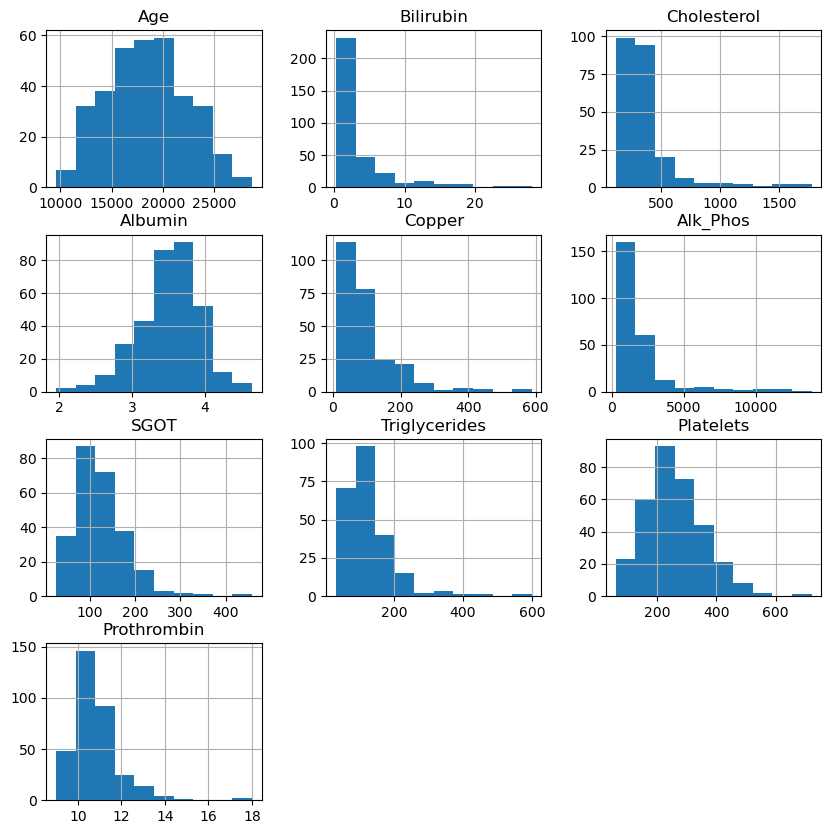

In [55]:
fig, ax = plt.subplots(figsize=(10,10))
df.hist(ax=ax);